In [1]:
import pyLIMA, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
from pyLIMA.fits import TRF_fit
from pyLIMA.models import FSPL_model,USBL_model,PSPL_model
from ipywidgets import interactive, HBox, VBox, Layout
from ipywidgets import (FloatSlider, FloatLogSlider, interactive_output, HBox, VBox, GridBox, Layout, Label)
from IPython.display import display
current_path = os.getcwd()
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
import pyLIMA_plots
from astropy import units as u
from astropy import constants as C
from pyLIMA.xallarap.xallarap import xallarap_shifts, compute_xallarap_curvature
import scipy.optimize as so
import numpy as np
import pandas as pd
import astropy.units as u



Parent Directory: /home/anibal/binary_source


In [2]:
def orbital_period_kepler(a_au, M_tot_Msun):
    """
    Compute the orbital period of a binary system using Kepler's third law
    in astronomical units.

    Parameters
    ----------
    a_au : float or array-like
        Semimajor axis in astronomical units (AU).
    M_tot_Msun : float or array-like
        Total mass of the system in solar masses (M_sun).

    Returns
    -------
    P_yr : float or ndarray
        Orbital period in years.
    """
    a_au = np.asarray(a_au, dtype=float)
    M_tot_Msun = np.asarray(M_tot_Msun, dtype=float)
    print("Period ", np.sqrt(a_au**3 / M_tot_Msun), "years")
    print("converting to ", np.sqrt(a_au**3 / M_tot_Msun)*365.25, "days (to use in pyLIMA)")
    return np.sqrt(a_au**3 / M_tot_Msun)*365.25*(1/u.day)

In [3]:

def a_from_P_kepler(P_days, Mtot_Msun):
    P_yr = np.asarray(P_days, float) / 365.25
    return (Mtot_Msun * P_yr**2)**(1/3)  # AU

# dentro del loop en P:
# Mtot = M1_Msun + M2_Msun  # o Mtot fijo que elijas
# a_AU = a_from_P_kepler(P, Mtot)
# xiE  = a_AU / rEhat_AU
# omega = 2*np.pi / P


In [4]:


def build_case(case_name, DS, DL, rEhat, v_perp, a, M1, M2,
               t0=50, u0=0.1, xi_phase=0, xi_inclination=np.pi/2, flux_ratio=0.2):
    """
    Construye un diccionario con los parámetros de un caso de xallarap.
    """
    q_xi = (M2 / M1).decompose().value
    P = orbital_period_kepler(a, M1 + M2)

    # tE = (rEhat * DL / DS) / v_perp
    tE = (rEhat) / v_perp
    return {
        "case": case_name,
        "DS_kpc": DS.to(u.kpc).value,
        "DL_kpc": DL.to(u.kpc).value,
        "rEhat_AU": rEhat.to(u.AU).value,
        "v_perp_kms": v_perp.to(u.km/u.s).value,
        "a_AU": a.to(u.AU).value,
        "M1_Msun": M1.to(u.M_sun).value,
        "M2_Msun": M2.to(u.M_sun).value,
        "xi_mass_ratio": q_xi,
        "tE": tE.to(u.day).value,
        "t0": t0,
        "u0": u0,
        "xiE": (a / rEhat).decompose().value,
        "omega_xi_1_per_day": (2*np.pi / P).value,
        "xi_phase": xi_phase,
        "xi_inclination": xi_inclination,
        "flux_ratio": flux_ratio,
        "P": P.value,
    }

DS = 8 * u.kpc
DL = 4 * u.kpc
v_perp = 50 * u.km / u.s
a = 2 * u.AU

rows = []

# =========================
# rEhat = 5 AU
# =========================

rEhat = 5 * u.AU

# Case 1: face-on, P > tE
rows.append(build_case(
    "case1", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun
))

# Case 2: face-on, P < tE
rows.append(build_case(
    "case2", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun
))

# Case 3a: edge-on, low mass ratio
rows.append(build_case(
    "case3a", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun,
    xi_inclination=np.pi/2
))

# Case 3b: edge-on, high mass ratio
rows.append(build_case(
    "case3b", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun,
    xi_inclination=np.pi/2
))

# =========================
# rEhat = 2 AU  (Case 4)
# =========================
rEhat = 2 * u.AU

rows.append(build_case(
    "case4-1", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun,
    xi_inclination=0
))

rows.append(build_case(
    "case4-2", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun,
    xi_inclination=0
))

rows.append(build_case(
    "case4-3a", DS, DL, rEhat, v_perp, a,
    M1=2*u.M_sun, M2=1.4*u.M_sun,
    xi_inclination=np.pi/2
))

rows.append(build_case(
    "case4-3b", DS, DL, rEhat, v_perp, a,
    M1=1.4*u.M_sun, M2=100*u.M_sun,
    xi_inclination=np.pi/2
))

df_cases = pd.DataFrame(rows).set_index("case")
df_cases


Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)
Period  1.5339299776947408 years
converting to  560.2679243530041 days (to use in pyLIMA)
Period  0.2808833628231621 years
converting to  102.59264827115996 days (to use in pyLIMA)


,DS_kpc,DL_kpc,rEhat_AU,v_perp_kms,a_AU,M1_Msun,M2_Msun,xi_mass_ratio,tE,t0,u0,xiE,omega_xi_1_per_day,xi_phase,xi_inclination,flux_ratio,P
case,,,,,,,,,,,,,,,,,
case1,8.0,4.0,5.0,50.0,2.0,2.0,1.4,0.700000,173.145684,50,0.1,0.4,0.011215,0,1.570796,0.2,560.267924
case2,8.0,4.0,5.0,50.0,2.0,1.4,100.0,71.428571,173.145684,50,0.1,0.4,0.061244,0,1.570796,0.2,102.592648
case3a,8.0,4.0,5.0,50.0,2.0,2.0,1.4,0.700000,173.145684,50,0.1,0.4,0.011215,0,1.570796,0.2,560.267924
case3b,8.0,4.0,5.0,50.0,2.0,1.4,100.0,71.428571,173.145684,50,0.1,0.4,0.061244,0,1.570796,0.2,102.592648
case4-1,8.0,4.0,2.0,50.0,2.0,2.0,1.4,0.700000,69.258273,50,0.1,1.0,0.011215,0,0.000000,0.2,560.267924
case4-2,8.0,4.0,2.0,50.0,2.0,1.4,100.0,71.428571,69.258273,50,0.1,1.0,0.061244,0,0.000000,0.2,102.592648
case4-3a,8.0,4.0,2.0,50.0,2.0,2.0,1.4,0.700000,69.258273,50,0.1,1.0,0.011215,0,1.570796,0.2,560.267924
case4-3b,8.0,4.0,2.0,50.0,2.0,1.4,100.0,71.428571,69.258273,50,0.1,1.0,0.061244,0,1.570796,0.2,102.592648


# Create event, define telescope and choose a model

PyLIMA need that we specify the compontents of $\xi_{E}=(\xi_{E \parallel},\xi_{E \perp}) = $.

Where $\xi_{E \parallel}=\xi_E \cos(\theta)$ and $\xi_{E \perp}=\xi_E \sin(\theta)$.


In [5]:



def mag(zp, Flux):
    '''
    Transform the flux to magnitude
    inputs
    zp: zero point
    Flux: vector that contains the lightcurve flux
    '''
    return zp - 2.5 * np.log10(abs(Flux))

def chi2_theoretical(fit_params, your_model, use_magnification=False):
    """
    Theoretical objective: unweighted L2 distance between data and model.

    Parameters
    ----------
    fit_params : array-like
        Parameter vector in the order defined by your_model.model_dictionnary.
    your_model : pyLIMA model instance
    use_magnification : bool
        If True, compares A(t) vs A_data stored in telescope.lightcurve['flux'].
        If False, compares F(t) vs flux data (pyLIMA photometry model).
    """
    list_params =  np.concatenate([fit_params, [1.0, 1.0]])
    
    py_params = your_model.compute_pyLIMA_parameters(list_params)

    sse = 0.0
    for telescope in your_model.event.telescopes:
        if telescope.lightcurve is None:
            continue

        # Data (what you put in telescope.lightcurve['flux'])
        data = telescope.lightcurve['flux'].value

        if use_magnification:
            # Compare magnifications directly:
            # model.model_magnification returns A(t)
            model_pred = your_model.model_magnification(telescope, py_params)
        else:
            # Compare photometric flux model directly: F(t) = f_s A(t) + f_b
            model_pred = your_model.compute_the_microlensing_model(
                telescope, py_params
            )['photometry']

        resid = data - model_pred
        sse += np.sum(resid**2)

    return sse



simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-500, 500, 5000)
lightcurve_sim = np.c_[t, np.full_like(t, 19.0), np.full_like(t, 0.000000001)]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time','mag','err_mag'],
    lightcurve_units=['JD','mag','mag'],
    location='Earth'
)
simulated_event.telescopes.append(tel)


case_name, df_row =  "case2", df_cases.loc["case2"]
params_list = [0]*12
model_xiE = PSPL_model.PSPLmodel(simulated_event, parallax=['None', 0], double_source=['Circular', df_row['t0']]) # <--- Here I set t0,xi = t0
model_xiE.define_model_parameters()



rE = 10*u.AU
a_au=1*u.AU
M1=2*u.M_sun
M2=1*u.M_sun
M_tot_Msun =M1+M2
xiE = (a/rE).decompose()#df_row['xiE']
t_0 = 50#df_row['t0']
t_E = 173#df_row['tE']
P = orbital_period_kepler(a_au, M_tot_Msun).value#df_row['P']
print(P)
u_0 = 0.1#df_row['u0']
phi_0 = 0#df_row['xi_phase']
binary_flux_ratio = 0#df_row['flux_ratio']
q = M1/M2#df_row['xi_mass_ratio']
fb = 1
fs=1
theta =0 
lambda_xi = df_row['xi_inclination']
omega = 2*np.pi/P
# for case_name, df_row in df_cases.iterrows():

params_list[0] = t_0#- df_row['xiE']*np.cos(df_row['xi_phase'])*df_row['tE'] 
params_list[1] = u_0# +df_row['xiE']*np.sin(df_row['xi_phase'])
params_list[2] = t_E 
params_list[3] = xiE*np.cos(theta) # <---- THE SOURCE BINARY SISTEM MOVES PARALLEL TO THE SEMI MAJOR AXIS
params_list[4] = xiE*np.sin(theta) # <---- THE SOURCE BINARY SISTEM MOVES PARALLEL TO THE SEMI MAJOR AXIS
params_list[5] = omega
params_list[6] = phi_0   #< ---- Orbital phase at t0
params_list[7] = lambda_xi #pi/2
params_list[8] = q
params_list[9] = binary_flux_ratio
params_list[10] = fs 
params_list[11] = fb 

py_params_xiE = model_xiE.compute_pyLIMA_parameters(params_list)
# A = model_xiE.model_magnification(model_xiE.event.telescopes[0], py_params_xiE)

simulator.simulate_lightcurve(model_xiE, py_params_xiE)
# k=0
# model_flux_xiE = model_xiE.compute_the_microlensing_model(simulated_event.telescopes[k],
                                                             # py_params_xiE)['photometry']
for k in range(len(simulated_event.telescopes)):
    model_flux = model_xiE.compute_the_microlensing_model(simulated_event.telescopes[k],
                                                             py_params_xiE)['photometry']
    simulated_event.telescopes[k].lightcurve['flux'] = model_flux #con esto el flujo es el teorico sin errores
    simulated_event.telescopes[k].lightcurve['mag'] = mag(27,model_flux)



model_PSPL = PSPL_model.PSPLmodel(simulated_event, parallax=['None', 0], double_source=['None', 0])
your_guess = [t_0,u_0,t_E]

result = so.minimize(
    chi2_theoretical,
    x0=np.array(your_guess, dtype=float),
    args=(model_PSPL, False),     
    method='Nelder-Mead',
    options=dict(maxiter=20000, xatol=1e-10, fatol=1e-10)
)


flux_PSPL_fit = model_PSPL.compute_the_microlensing_model(
                model_PSPL.event.telescopes[0], model_PSPL.compute_pyLIMA_parameters(np.concatenate([result["x"], [fs, fb]]))
            )['photometry']


# plt.plot(model_xiE.event.telescopes[0].lightcurve['time'],model_xiE.event.telescopes[0].lightcurve['flux'], label="True model xallarap")

# plt.plot(t , flux_PSPL_fit,label = "fit pyLIMA PSPL")

resid = model_xiE.event.telescopes[0].lightcurve['flux'] - flux_PSPL_fit
RMS = float(np.sqrt(np.mean(resid**2)))
# plt.title("RMS: "+str(RMS) )
# plt.xlabel("time [days] ")
# plt.ylabel("Flux primary source (flux companion = 0)")
# plt.legend()

# A_truth (xallarap)
A_truth = model_xiE.model_magnification(
    model_xiE.event.telescopes[0], py_params_xiE
)

# A_fit (PSPL con params ajustados)
best_full = np.concatenate([result["x"], [fs, fb]])  # ojo: en tu modelo esto quizás es fsource, ftotal
py_best = model_PSPL.compute_pyLIMA_parameters(best_full)
A_fit = model_PSPL.model_magnification(
    model_PSPL.event.telescopes[0], py_best
)

RMS_A = float(np.sqrt(np.mean((A_truth - A_fit)**2)))
print("RMS in magnification =", RMS_A)


Period  0.5773502691896257 years
converting to  210.8771858215108 days (to use in pyLIMA)
210.8771858215108
RMS in magnification = 0.42975051838927797


OrderedDict([('t0', 50.0), ('u0', 0.2), ('tE', 173.0), ('xi_para', 0.1), ('xi_perp', 0.0), ('xi_angular_velocity', 0.0072637980429821804), ('xi_phase', 0.0), ('xi_inclination', 1.5707963267948966), ('xi_mass_ratio', 1.0), ('q_flux_G', 0), ('fsource_Simulation', 27.92543841237335), ('ftotal_Simulation', 27.92543841237335)])
[ 50.    0.2 173. ]
Fit success
Z_A = 0.2618854819719006


/tmp/ipykernel_25008/3837918759.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


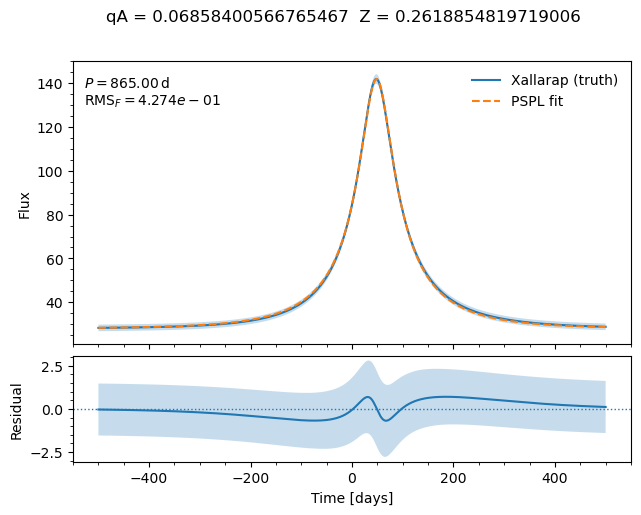

Best-fit (t0,u0,tE) = [ 48.39172529   0.19967402 172.60261644]
RMS_F = 0.42740611288960206
RMS_A = 0.01530526062216537


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as so
from scipy.stats import chi2
from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.simulations import simulator
import numpy as np
from scipy.interpolate import interp1d

mag = np.array([
    12.0, 12.5, 13.0, 13.5, 14.0, 14.5,
    15.0, 15.5, 16.0, 16.5, 17.0, 17.5,
    18.0, 18.5, 19.0, 19.5, 20.0, 20.5,
    21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
    24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0
])

sigma_W149 = np.array([
    0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
    0.0010475, 0.0011229, 0.0012038, 0.0013207,
    0.0015178, 0.0017852, 0.002139, 0.0025867,
    0.0032066, 0.0039261, 0.0050352, 0.0063881,
    0.0082817, 0.01087, 0.014603, 0.019616,
    0.027602, 0.039749, 0.058585, 0.088371,
    0.13351, 0.20964, 0.32165, 0.51373, 1.0
])

# Interpolación en log10(sigma)
sigma_interp_log = interp1d(
    mag,
    np.log10(sigma_W149),
    kind="linear",
    bounds_error=True
)

def sigma_W149_func(W149):
    """
    Devuelve sigma_W149 [mag / 15 min] para una magnitud W149.

    Válido para 12 <= W149 <= 27.
    """
    W149 = np.asarray(W149)

    log_sigma = sigma_interp_log(W149)
    sigma = 10**log_sigma

    return sigma


def mag_to_flux(mag, zp=0.0):
    return 10**(-0.4 * (mag - zp))

def sigma_flux_from_sigma_mag(mag, sigma_mag, zp=0.0):
    F = mag_to_flux(mag, zp)
    sigma_F = 0.921034 * F * sigma_mag
    return sigma_F


def flux_to_mag(flux, zp=ZP):
    flux = np.asarray(flux)
    return zp - 2.5 * np.log10(flux)

def sigma_flux_from_flux(flux, zp=ZP):
    """
    Devuelve el error absoluto en flujo usando la curva sigma_W149(mag).
    
    Requiere que sigma_W149_func(mag) ya esté definida.
    """
    flux = np.asarray(flux)

    mag = flux_to_mag(flux, zp=zp)
    sigma_mag = sigma_W149_func(mag)

    sigma_flux = (np.log(10) / 2.5) * flux * sigma_mag

    return sigma_flux



# ZP = 27.615

# flux_array = np.array([1e2, 1e3, 1e4])

# err_flux_array = sigma_flux_from_flux(flux_array)

# mag = np.array([22,23])
# sigma_mag = sigma_W149_func(mag)
# sigma_F = sigma_flux_from_sigma_mag(mag, sigma_mag, zp=27.615)

# print(sigma_F)

# mag_to_flux(16, zp=27.4)
# =========================
# helpers
# =========================
def mag(zp, Flux):
    return zp - 2.5 * np.log10(np.abs(Flux))

def chi2_theoretical(fit_params, your_model, use_magnification=False,
                     fs_fixed=1.0, fsecond_fixed=1.0):
    """
    SSE sin pesos. Ajusta SOLO (t0,u0,tE). Flujos fijos.
    OJO: fsecond_fixed acá representa tu segundo parámetro de flujo (fb o ftotal según tu modelo).
    """
    fit_params = np.asarray(fit_params, dtype=float)
    full_params = np.concatenate([fit_params, [fs_fixed, fsecond_fixed]])
    py_params = your_model.compute_pyLIMA_parameters(full_params)

    sse = 0.0
    for tel in your_model.event.telescopes:
        if tel.lightcurve is None:
            continue

        data = tel.lightcurve["flux"].value

        if use_magnification:
            model_pred = your_model.model_magnification(tel, py_params)
        else:
            model_pred = your_model.compute_the_microlensing_model(tel, py_params)["photometry"]

        resid = data - model_pred
        sse += np.sum(resid**2)

    return float(sse)

def build_sim_event(t, mag0=19.0, emag=1e-9, filt="G"):
    ev = event.Event()
    ev.name = "Simulated"
    ev.ra = 170
    ev.dec = -70

    lc = np.c_[t, np.full_like(t, mag0), np.full_like(t, emag)]
    tel = telescopes.Telescope(
        name="Simulation",
        camera_filter=filt,
        lightcurve=lc.astype(float),
        lightcurve_names=["time", "mag", "err_mag"],
        lightcurve_units=["JD", "mag", "mag"],
        location="Earth",
    )
    ev.telescopes.append(tel)
    return ev

# =========================
# MAIN: single-period reproduction
# =========================
def single_period_fit_and_plot(
    P_days: float,
    # PSPL base
    t0_true: float = 50.0,
    u0_true: float = 0.1,
    tE_true: float = 173.0,
    # xallarap geometry
    xiE: float = 0.1,              # default; si querés Kepler-consistente, calculalo afuera
    theta: float = 0.0,
    phi0: float = 0.0,
    lambda_xi: float = 0.5*np.pi,  # inclinación fija
    q_mass: float = 1.0,           # M2/M1 o M1/M2 según convención de pyLIMA; mantené consistente con tu uso
    qflux: float = 0.0,
    # photometry
    ms: float = 1.0,
    mtotal: float = 1.0,          
    # isolate knobs
    override_xiE: float | None = None,
    window_k: float | None = None, # ej 5.0 para |t-t0|<5 tE
    out_prefix: str = "singleP",
):
    """
    Genera Xallarap truth para un solo P, ajusta PSPL y grafica.

    override_xiE:
      - None: usa xiE tal cual lo pasaste
      - float: fuerza xiE a ese valor (útil para aislar el efecto de omega)
    window_k:
      - None: plotea todo el rango temporal
      - float: plotea solo |t-t0| <= window_k * tE_true
    """
    # time grid
    t = np.linspace(-500, 500, 5000)

    # omega
    omega = 2.0*np.pi/float(P_days)

    # xiE override
    if override_xiE is not None:
        xiE_use = float(override_xiE)
    else:
        xiE_use = float(xiE)

    xi_para = xiE_use*np.cos(theta)
    xi_perp = xiE_use*np.sin(theta)

    # event
    ev = build_sim_event(t, mag0=19.0, emag=1e-9, filt="G")

    # -------- truth model (xallarap)
    model_xal = PSPL_model.PSPLmodel(ev, parallax=["None", 0.0], double_source=["Circular", t0_true])
    model_xal.define_model_parameters()
    ZP =27.615
    fs = mag_to_flux(ms, zp=ZP)
    ftotal =mag_to_flux(mtotal, zp=ZP)
    
    params_xal = [
        t0_true, u0_true, tE_true,
        xi_para, xi_perp, omega,
        phi0, lambda_xi,
        q_mass, qflux,
        fs, ftotal,
    ]
    py_params_xal = model_xal.compute_pyLIMA_parameters(params_xal)
    print(py_params_xal)
    # simulate + set theoretical flux data
    simulator.simulate_lightcurve(model_xal, py_params_xal)

    F_truth = model_xal.compute_the_microlensing_model(ev.telescopes[0], py_params_xal)["photometry"]
    ev.telescopes[0].lightcurve["flux"] = F_truth
    ev.telescopes[0].lightcurve["mag"] = mag(27.615, F_truth)

    # -------- PSPL fit model
    model_pspl = PSPL_model.PSPLmodel(ev, parallax=["None", 0.0], double_source=["None", 0.0])
    model_pspl.define_model_parameters()

    x0 = np.array([t0_true, u0_true, tE_true], dtype=float)
    print(x0)
    res = so.minimize(
        chi2_theoretical,
        x0=x0,
        args=(model_pspl, False, fs, ftotal),  # fit en flujo
        method="Nelder-Mead",
        options=dict(maxiter=200000, xatol=1e-10, fatol=1e-6),
    )
    print("Fit success")
    if not res.success:
        raise RuntimeError(f"Fit failed: {res.message}")

    best = np.asarray(res.x, dtype=float)

    # reconstruct fitted curves
    best_full = np.concatenate([best, [fs, ftotal]])
    
    t0_ml, u0_ml, tE_ml = best_full[0],best_full[1],best_full[2]
    py_best = model_pspl.compute_pyLIMA_parameters(best_full)

    F_fit = model_pspl.compute_the_microlensing_model(ev.telescopes[0], py_best)["photometry"]
    A_truth = model_xal.model_magnification(ev.telescopes[0], py_params_xal)
    A_fit   = model_pspl.model_magnification(ev.telescopes[0], py_best)
    
   

    # residuals
    resid_F = F_truth - F_fit
    resid_A = A_truth - A_fit
    
    # optional window
    if window_k is not None:
        mask = np.abs(t - t0_true) <= float(window_k)*tE_true
    else:
        mask = np.ones_like(t, dtype=bool)

    rms_F = float(np.sqrt(np.mean((resid_F[mask])**2)))
    rms_A = float(np.sqrt(np.mean((resid_A[mask])**2)))
    if True:
        mag_truth = flux_to_mag(F_truth)
        mag_fit   = flux_to_mag(F_fit)
        
        mask = (
            mask
            & (mag_truth >= 12.0) & (mag_truth <= 27.0)
            & (mag_fit   >= 12.0) & (mag_fit   <= 27.0)
        )
        F_truth_m = F_truth[mask]
        F_fit_m   = F_fit[mask]
        
        err_truth = sigma_flux_from_flux(F_truth_m)
        err_fit   = sigma_flux_from_flux(F_fit_m)
        residuals = F_truth_m - F_fit_m
        
        # estadístico q_A (chi^2)
        q_A = np.sum((residuals / err_truth)**2)/(5000-3)
        
        
        Z_A = np.sqrt(q_A)
        
        # print("q_A =", q_A)
        print("Z_A =", Z_A)

        # N = len(F_truth_m)
        # k_pspl = 3 
        
        # nu = N - k_pspl
        
        # p_value = chi2.sf(q_A, df=nu)
        
        # print("N =", N)
        # print("dof =", nu)
        # print("p-value =", p_value)
    # =========================
    # plots: FLUX + residual
    # =========================
    if True:
        fig = plt.figure(figsize=(7.2, 5.2))
        gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.2], hspace=0.06)
        ax = fig.add_subplot(gs[0, 0])
        axr = fig.add_subplot(gs[1, 0], sharex=ax)
        
        mag_truth = flux_to_mag(F_truth)
        mask = mask & (mag_truth >= 12.0) & (mag_truth <= 27.0)
        
        err_flux_array = sigma_flux_from_flux(F_truth[mask])
        
        ax.plot(
            t[mask],
            F_truth[mask],
            label="Xallarap (truth)"
        )
        
        ax.fill_between(
            t[mask],
            F_truth[mask] - err_flux_array,
            F_truth[mask] + err_flux_array,
            alpha=0.25
        )
        
        ax.plot(t[mask], F_fit[mask], "--", label="PSPL fit")
        ax.set_ylabel("Flux")
        ax.legend(frameon=False, loc="best")
        
        ax.text(
            0.02, 0.95,
            rf"$P={P_days:.2f}\,\mathrm{{d}}$" + "\n" + rf"$\mathrm{{RMS}}_F={rms_F:.3e}$",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.85),
        )
        
        axr.plot(t[mask], resid_F[mask])
        
        axr.fill_between(
            t[mask],
            resid_F[mask] - err_flux_array,
            resid_F[mask] + err_flux_array,
            alpha=0.25
        )
        axr.axhline(0.0, linestyle=":", linewidth=1.0)
        axr.set_xlabel("Time [days]")
        axr.set_ylabel("Residual")
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        axr.yaxis.set_minor_locator(AutoMinorLocator())
        axr.xaxis.set_minor_locator(AutoMinorLocator())
        plt.setp(ax.get_xticklabels(), visible=False)
        plt.suptitle(f"qA = {q_A}  Z = {Z_A}")
        fig.tight_layout()
        fig.savefig(f"{out_prefix}_flux.pdf", bbox_inches="tight")
        fig.savefig(f"{out_prefix}_flux.png", bbox_inches="tight")
        plt.show()

    # =========================
    # plots: MAGNIFICATION + residual
    # =========================
    if False:
        fig = plt.figure(figsize=(7.2, 5.2))
        gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.2], hspace=0.06)
        ax = fig.add_subplot(gs[0, 0])
        axr = fig.add_subplot(gs[1, 0], sharex=ax)
    
        ax.plot(t[mask], np.log10(A_truth[mask]), label="Xallarap (truth)")
        ax.plot(t[mask], np.log10(A_fit[mask]), "--", label="PSPL fit")
        ax.set_ylabel(r"Magnification $A(t)$")
        ax.legend(frameon=False, loc="best")
        INT_L1 = float(np.trapz(np.abs(resid_A[mask]), t[mask]))
        ax.text(
            0.02, 0.95,
            rf"$P={P_days:.2f}\,\mathrm{{d}}$" + "\n" + rf"$\mathrm{{RMS}}_A={rms_A:.3e}$"+"\n"+f"Int L1= {round(INT_L1,3)}"+"\n"+r"MAX $|F_\xi-F_{PSPL}|$="+f" {round(max(abs(resid_F)),3)}",
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.85),
        )
    
        axr.plot(t[mask], resid_A[mask])
        axr.axhline(0.0, linestyle=":", linewidth=1.0)
        axr.set_xlabel("Time [days]")
        axr.set_ylabel(r"$\Delta A$")
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        axr.yaxis.set_minor_locator(AutoMinorLocator())
        axr.xaxis.set_minor_locator(AutoMinorLocator())
        plt.setp(ax.get_xticklabels(), visible=False)
       
        
        fig.tight_layout()
        fig.savefig(f"{out_prefix}_mag.pdf", bbox_inches="tight")
        fig.savefig(f"{out_prefix}_mag.png", bbox_inches="tight")
        plt.show()

    print("Best-fit (t0,u0,tE) =", best)
    print("RMS_F =", rms_F)
    print("RMS_A =", rms_A)

    return dict(
        t=t,
        mask=mask,
        best=best,
        F_truth=F_truth,
        F_fit=F_fit,
        A_truth=A_truth,
        A_fit=A_fit,
        RMS_F=rms_F,
        RMS_A=rms_A,
    )



%matplotlib inline
plt.close("all")
out = single_period_fit_and_plot(
    P_days=173*5,
    t0_true=50.0, u0_true=0.2, tE_true=173.0,
    xiE=0.1,            # poné tu valor
    theta=0.0, phi0=0.0,
    lambda_xi=0.5*np.pi,
    q_mass=1.0, qflux=0,
    ms=24,
    mtotal=24,        
    override_xiE=None,  # 
    window_k=5.0,       # 
    out_prefix="singleP_210d",
)